## Importamos las Librerías:

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Establecemos los Parámetros de los Gráficos:

In [2]:
sns.set_style("white")
sns.set_context("notebook")
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'stix',
    'font.serif': 'Times New Roman',
    'figure.figsize': (11, 9.4),
    'axes.edgecolor': 'white',
    'axes.labelcolor': '#333333',
    'axes.titlesize': 20,
    'axes.titlecolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

## Cargamos el Conjunto de Datos:

In [3]:
data = pd.read_csv('~/homicidios/data/final/homicidios_final.csv')
data

,ent_regis,ent_resid,tloc_ocurr,causa_def,cod_adicio,lista_mex,sexo,afromex,conindig,lengua,...,area_ur,edad_agru,complicaro,dia_cert,mes_cert,anio_cert,maternas,razon_m,estado_defuncion_registrada,estado_defuncion_residencia
0,1,32,500 000 a 999 999 habitantes,"Neumonía, no especificada",NaN,Neumonía,Mujer,No,No,No,...,Urbana,De 70 a 74 años,No especificada,Dieciocho días,Diciembre,2022,NaN,NaN,Aguascalientes,Zacatecas
1,1,1,500 000 a 999 999 habitantes,Síndrome de dificultad respiratoria del adulto,NaN,Las demás enfermedades del aparato respiratorio,Mujer,No,No,No,...,Urbana,De 75 a 79 años,No especificada,Doce días,Diciembre,2022,NaN,NaN,Aguascalientes,Aguascalientes
2,1,1,500 000 a 999 999 habitantes,Enfermedad pulmonar obstructiva crónica con in...,NaN,Enfermedades pulmonares obstructivas crónicas,Mujer,No,No,No,...,Urbana,De 65 a 69 años,No especificada,Diecisiete días,Diciembre,2022,NaN,NaN,Aguascalientes,Aguascalientes
3,1,1,500 000 a 999 999 habitantes,Desnutrición proteicocalórica leve,NaN,Otras desnutriciones proteinocalóricas,Mujer,No,No,No,...,Urbana,De 90 a 94 años,No especificada,Un día,Enero,2023,NaN,NaN,Aguascalientes,Aguascalientes
4,1,14,500 000 a 999 999 habitantes,Cirrosis hepática alcohólica,NaN,Enfermedad alcohólica del hígado,Hombre,No,No,No,...,Rural,De 45 a 49 años,No aplica,Veintidós días,Diciembre,2022,NaN,NaN,Aguascalientes,Jalisco
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799864,32,32,20 000 a 29 999 habitantes,"Síndrome de aspiración neonatal, sin otra espe...",NaN,Dificultad respiratoria del recién nacido y ot...,Mujer,No,No,No aplica a menores de 3 años,...,Urbana,Menores de un año,No aplica,No especificado,Diciembre,2023,NaN,NaN,Zacatecas,Zacatecas
799865,32,32,100 000 a 249 999 habitantes,"Kernicterus, no especificado",NaN,Las demás afecciones originadas en el período ...,Mujer,No,No,No aplica a menores de 3 años,...,Urbana,Menores de un año,No aplica,Cinco días,Junio,2023,NaN,NaN,Zacatecas,Zacatecas
799866,32,32,100 000 a 249 999 habitantes,Síndrome de dificultad respiratoria del recién...,NaN,Dificultad respiratoria del recién nacido y ot...,Mujer,No,No,No aplica a menores de 3 años,...,Urbana,Menores de un año,No aplica,Nueve días,Agosto,2023,NaN,NaN,Zacatecas,Zacatecas
799867,32,32,100 000 a 249 999 habitantes,Gastrosquisis,NaN,Otras malformaciones congénitas y deformidades...,Mujer,No,No,No aplica a menores de 3 años,...,Urbana,Menores de un año,No aplica,Diecinueve días,Septiembre,2023,NaN,NaN,Zacatecas,Zacatecas


## Enraizamos el Proyecto:

In [4]:
import sys, os
sys.path.append(os.path.abspath(".."))

%load_ext autoreload
%autoreload 2

## Importamos las Funciones Modulares:

In [5]:
import modules.sustituir_nulos
from modules.sustituir_nulos import sustituir_nulos_pd
from modules.eliminar_variables import eliminar_variables_pd
from modules.eliminar_variables import variables_ml

In [6]:
data = eliminar_variables_pd(df= data, variables= variables_ml)

In [7]:
data.shape

(799869, 42)

## Sustituimos Valores Nulos:

In [8]:
data = sustituir_nulos_pd(df= data, variable= 'lista_mex', text= 'Sin Registros')
data = sustituir_nulos_pd(df= data, variable= 'estado_defuncion_residencia', text= 'Sin Registros')

## Corroboramos Ausencia de Valores Nulos:

In [9]:
data.isnull().sum().sort_values(ascending=False).head(10)

tloc_ocurr    0
causa_def     0
lista_mex     0
sexo          0
afromex       0
conindig      0
lengua        0
cve_lengua    0
nacionalid    0
nacesp_cve    0
dtype: int64

## Reducimos el Conjunto de Datos:

In [10]:
data = data[data['tipo_defun']=='Homicidio (Agresión)']

In [11]:
data['causa_def'].value_counts()

causa_def
Agresión con disparo de otras armas de fuego, y las no especificadas en calles y carreteras        11708
Agresión con disparo de otras armas de fuego, y las no especificadas en lugar no especificado       4431
Agresión con disparo de otras armas de fuego, y las no especificadas en vivienda                    2622
Agresión con disparo de otras armas de fuego, y las no especificadas en otro lugar especificado     2023
Agresión por medios no especificados en lugar no especificado                                       1385
                                                                                                   ...  
Agresión con fuerza corporal en área industrial y de la construcción                                   1
Agresión con plaguicidas en granja                                                                     1
Agresión con objeto romo o sin filo en institución residencial                                         1
Agresión por colisión de vehículo de motor en

## Creamos la Variable Clasificadora:

In [12]:
data['feminmuj'] = ['Sí' if tipo_defun == 'Homicidio (Agresión)' and sexo == 'Mujer' else 'No' 
                          for tipo_defun, sexo in zip(data['tipo_defun'], data['sexo'])]

data

,tloc_ocurr,causa_def,lista_mex,sexo,afromex,conindig,lengua,cve_lengua,nacionalid,nacesp_cve,...,minutos,capitulo,lista1,area_ur,edad_agru,dia_cert,mes_cert,estado_defuncion_registrada,estado_defuncion_residencia,feminmuj
814,500 000 a 999 999 habitantes,Agresión con objeto cortante en lugar no espec...,Agresiones (homicidios),Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),...,Trece minutos,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 20 a 24 años,Dieciséis días,Enero,Aguascalientes,Aguascalientes,No
847,500 000 a 999 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Agresiones (homicidios),Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),...,Treinta minutos,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 25 a 29 años,Siete días,Marzo,Aguascalientes,Aguascalientes,No
888,10 000 a 14 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Agresiones (homicidios),Mujer,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),...,No especificado,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 15 a 19 años,Veinticuatro días,Marzo,Aguascalientes,Aguascalientes,Sí
889,500 000 a 999 999 habitantes,Agresión con objeto romo o sin filo en calles ...,Agresiones (homicidios),Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),...,Nueve minutos,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 40 a 44 años,Veintiséis días,Marzo,Aguascalientes,Aguascalientes,No
900,500 000 a 999 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Agresiones (homicidios),Mujer,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),...,No especificado,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 55 a 59 años,Tres días,Enero,Aguascalientes,Aguascalientes,Sí
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799848,100 000 a 249 999 habitantes,Agresión con objeto cortante en lugar no espec...,Agresiones (homicidios),Hombre,No,No,Sí,No especificado,Mexicana,Mexicana (no especificado de Entidad Federativa),...,No especificado,Factores suplementarios relacionados con causa...,Agresiones,Rural,De 15 a 19 años,No especificado,Septiembre,Zacatecas,Zacatecas,No
799849,100 000 a 249 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Agresiones (homicidios),Mujer,No,No,Sí,No especificado,Mexicana,Mexicana (no especificado de Entidad Federativa),...,No especificado,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 20 a 24 años,Veinticuatro días,Diciembre,Zacatecas,Zacatecas,Sí
799850,100 000 a 249 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Agresiones (homicidios),Hombre,No,No,Sí,No especificado,Mexicana,Mexicana (no especificado de Entidad Federativa),...,No especificado,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 20 a 24 años,Veintinueve días,Diciembre,Zacatecas,Zacatecas,No
799851,100 000 a 249 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Agresiones (homicidios),Hombre,No,No,Sí,No especificado,Mexicana,Mexicana (no especificado de Entidad Federativa),...,No especificado,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 40 a 44 años,Treinta y un días,Diciembre,Zacatecas,Zacatecas,No


In [13]:
data = data.drop(['tipo_defun', 'lista_mex', 'lista1'], axis=1)
data

,tloc_ocurr,causa_def,sexo,afromex,conindig,lengua,cve_lengua,nacionalid,nacesp_cve,edad,...,horas,minutos,capitulo,area_ur,edad_agru,dia_cert,mes_cert,estado_defuncion_registrada,estado_defuncion_residencia,feminmuj
814,500 000 a 999 999 habitantes,Agresión con objeto cortante en lugar no espec...,Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Veintiún años,...,Quince horas,Trece minutos,Factores suplementarios relacionados con causa...,Urbana,De 20 a 24 años,Dieciséis días,Enero,Aguascalientes,Aguascalientes,No
847,500 000 a 999 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Veintiocho años,...,Veintiún horas,Treinta minutos,Factores suplementarios relacionados con causa...,Urbana,De 25 a 29 años,Siete días,Marzo,Aguascalientes,Aguascalientes,No
888,10 000 a 14 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Mujer,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Dieciocho años,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Urbana,De 15 a 19 años,Veinticuatro días,Marzo,Aguascalientes,Aguascalientes,Sí
889,500 000 a 999 999 habitantes,Agresión con objeto romo o sin filo en calles ...,Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Cuarenta años,...,Nueve horas,Nueve minutos,Factores suplementarios relacionados con causa...,Urbana,De 40 a 44 años,Veintiséis días,Marzo,Aguascalientes,Aguascalientes,No
900,500 000 a 999 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Mujer,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Cincuenta y cinco años,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Urbana,De 55 a 59 años,Tres días,Enero,Aguascalientes,Aguascalientes,Sí
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799848,100 000 a 249 999 habitantes,Agresión con objeto cortante en lugar no espec...,Hombre,No,No,Sí,No especificado,Mexicana,Mexicana (no especificado de Entidad Federativa),Dieciocho años,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Rural,De 15 a 19 años,No especificado,Septiembre,Zacatecas,Zacatecas,No
799849,100 000 a 249 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Mujer,No,No,Sí,No especificado,Mexicana,Mexicana (no especificado de Entidad Federativa),Veinticuatro años,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Urbana,De 20 a 24 años,Veinticuatro días,Diciembre,Zacatecas,Zacatecas,Sí
799850,100 000 a 249 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Hombre,No,No,Sí,No especificado,Mexicana,Mexicana (no especificado de Entidad Federativa),Veinte años,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Urbana,De 20 a 24 años,Veintinueve días,Diciembre,Zacatecas,Zacatecas,No
799851,100 000 a 249 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Hombre,No,No,Sí,No especificado,Mexicana,Mexicana (no especificado de Entidad Federativa),Cuarenta años,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Urbana,De 40 a 44 años,Treinta y un días,Diciembre,Zacatecas,Zacatecas,No


## Convertimos a Numérica la Variable Objetivo:

In [14]:
data['feminmuj'].replace(to_replace='Sí', value = 1, inplace=True)
data['feminmuj'].replace(to_replace='No', value = 0, inplace=True)

In [15]:
data.head()

,tloc_ocurr,causa_def,sexo,afromex,conindig,lengua,cve_lengua,nacionalid,nacesp_cve,edad,...,horas,minutos,capitulo,area_ur,edad_agru,dia_cert,mes_cert,estado_defuncion_registrada,estado_defuncion_residencia,feminmuj
814,500 000 a 999 999 habitantes,Agresión con objeto cortante en lugar no espec...,Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Veintiún años,...,Quince horas,Trece minutos,Factores suplementarios relacionados con causa...,Urbana,De 20 a 24 años,Dieciséis días,Enero,Aguascalientes,Aguascalientes,0
847,500 000 a 999 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Veintiocho años,...,Veintiún horas,Treinta minutos,Factores suplementarios relacionados con causa...,Urbana,De 25 a 29 años,Siete días,Marzo,Aguascalientes,Aguascalientes,0
888,10 000 a 14 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Mujer,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Dieciocho años,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Urbana,De 15 a 19 años,Veinticuatro días,Marzo,Aguascalientes,Aguascalientes,1
889,500 000 a 999 999 habitantes,Agresión con objeto romo o sin filo en calles ...,Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Cuarenta años,...,Nueve horas,Nueve minutos,Factores suplementarios relacionados con causa...,Urbana,De 40 a 44 años,Veintiséis días,Marzo,Aguascalientes,Aguascalientes,0
900,500 000 a 999 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Mujer,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Cincuenta y cinco años,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Urbana,De 55 a 59 años,Tres días,Enero,Aguascalientes,Aguascalientes,1


In [16]:
data = data[data['sexo'] != 'No especificado']

In [17]:
data.shape

(31983, 40)

## Aplicamos Imblearn al Conjunto de Datos:

In [18]:
from imblearn.under_sampling import RandomUnderSampler
undersample = RandomUnderSampler(random_state=42)

In [19]:
X = data.drop('sexo',axis=1)
y = data.sexo

In [20]:
y.unique()

array(['Hombre', 'Mujer'], dtype=object)

In [21]:
X_over , y_over = undersample.fit_resample(X,y)

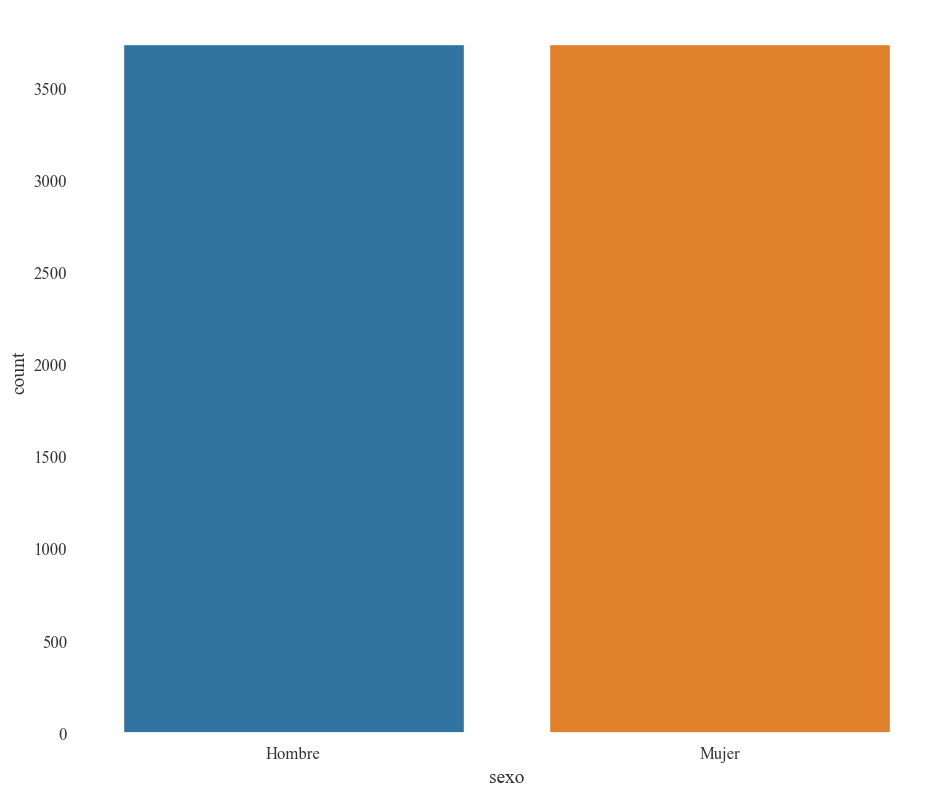

In [22]:
sns.countplot(x = y_over, data = data, hue = y_over) 
plt.xticks(rotation=0)
plt.show()

In [23]:
y_over.unique()

array(['Hombre', 'Mujer'], dtype=object)

In [24]:
y_over.value_counts()

sexo
Hombre    3739
Mujer     3739
Name: count, dtype: int64

In [25]:
y_over.value_counts(
    normalize = True
)

sexo
Hombre    0.5
Mujer     0.5
Name: proportion, dtype: float64

In [26]:
data.shape

(31983, 40)

In [27]:
X_over.shape

(7478, 39)

In [28]:
y_over.shape

(7478,)

In [29]:
data = X_over
data

,tloc_ocurr,causa_def,afromex,conindig,lengua,cve_lengua,nacionalid,nacesp_cve,edad,sem_gest,...,horas,minutos,capitulo,area_ur,edad_agru,dia_cert,mes_cert,estado_defuncion_registrada,estado_defuncion_residencia,feminmuj
471507,250 000 a 499 999 habitantes,Agresión por medios no especificados en calles...,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Cincuenta años,No aplica,...,Ocho horas,Seis minutos,Factores suplementarios relacionados con causa...,Urbana,De 50 a 54 años,Veintisiete días,Agosto,Morelos,Morelos,0
244571,250 000 a 499 999 habitantes,Agresión por medios no especificados en lugar ...,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Setenta y un años,No aplica,...,Veintidós horas,Treinta minutos,Factores suplementarios relacionados con causa...,Urbana,De 70 a 74 años,Veinte días,Julio,Guanajuato,Guanajuato,0
107072,500 000 a 999 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Treinta y cinco años,No aplica,...,Veintitrés horas,Cero minutos,Factores suplementarios relacionados con causa...,Urbana,De 35 a 39 años,Veinticuatro días,Agosto,Chihuahua,Chihuahua,0
443851,100 000 a 249 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Veintiséis años,No aplica,...,Veintidós horas,Cero minutos,Factores suplementarios relacionados con causa...,Urbana,De 25 a 29 años,Veinte días,Marzo,Michoacán,Michoacán,0
455318,500 000 a 999 999 habitantes,"Agresión por ahorcamiento, estrangulamiento y ...",No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Veinticuatro años,No aplica,...,Once horas,Siete minutos,Factores suplementarios relacionados con causa...,Urbana,De 20 a 24 años,Cinco días,Mayo,Michoacán,Michoacán,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799556,100 000 a 249 999 habitantes,Agresión con objeto cortante en lugar no espec...,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Veinticinco años,No aplica,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Urbana,De 25 a 29 años,Veintinueve días,Octubre,Zacatecas,Zacatecas,1
799565,100 000 a 249 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Veintiocho años,No aplica,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Urbana,De 25 a 29 años,Dos días,Diciembre,Zacatecas,Zacatecas,1
799572,100 000 a 249 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Cuarenta y ocho años,No aplica,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Urbana,De 45 a 49 años,Veinte días,Noviembre,Zacatecas,Zacatecas,1
799636,100 000 a 249 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Treinta y un años,No aplica,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Urbana,De 30 a 34 años,Ocho días,Noviembre,Zacatecas,Zacatecas,1


## Creamos una Copia del Dataframe:

In [30]:
df_data_processing = data.copy()

## Transformamos el Conjunto de Datos preprocesado en Dummies:

In [31]:
df_data_processing = pd.get_dummies(df_data_processing)
df_data_processing.head(5)

,dia_nacim,feminmuj,tloc_ocurr_1 000 000 a 1 499 999 habitantes,tloc_ocurr_1 000 a 1 999 habitantes,tloc_ocurr_1 500 000 y más habitantes,tloc_ocurr_1 a 999 habitantes,tloc_ocurr_10 000 a 14 999 habitantes,tloc_ocurr_100 000 a 249 999 habitantes,tloc_ocurr_15 000 a 19 999 habitantes,tloc_ocurr_2 000 a 2 499 habitantes,...,estado_defuncion_residencia_San Luis Potosí,estado_defuncion_residencia_Sin Registros,estado_defuncion_residencia_Sinaloa,estado_defuncion_residencia_Sonora,estado_defuncion_residencia_Tabasco,estado_defuncion_residencia_Tamaulipas,estado_defuncion_residencia_Tlaxcala,estado_defuncion_residencia_Veracruz,estado_defuncion_residencia_Yucatán,estado_defuncion_residencia_Zacatecas
471507,1,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
244571,4,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
107072,11,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
443851,16,0,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
455318,13,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [32]:
df_data_processing

,dia_nacim,feminmuj,tloc_ocurr_1 000 000 a 1 499 999 habitantes,tloc_ocurr_1 000 a 1 999 habitantes,tloc_ocurr_1 500 000 y más habitantes,tloc_ocurr_1 a 999 habitantes,tloc_ocurr_10 000 a 14 999 habitantes,tloc_ocurr_100 000 a 249 999 habitantes,tloc_ocurr_15 000 a 19 999 habitantes,tloc_ocurr_2 000 a 2 499 habitantes,...,estado_defuncion_residencia_San Luis Potosí,estado_defuncion_residencia_Sin Registros,estado_defuncion_residencia_Sinaloa,estado_defuncion_residencia_Sonora,estado_defuncion_residencia_Tabasco,estado_defuncion_residencia_Tamaulipas,estado_defuncion_residencia_Tlaxcala,estado_defuncion_residencia_Veracruz,estado_defuncion_residencia_Yucatán,estado_defuncion_residencia_Zacatecas
471507,1,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
244571,4,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
107072,11,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
443851,16,0,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
455318,13,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799556,27,1,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
799565,30,1,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
799572,14,1,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
799636,6,1,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True


## Aplicamos la Escalabilidad de los Datos:

In [33]:
from sklearn.preprocessing import MinMaxScaler

In [34]:
scaler = MinMaxScaler()
df_data_processing_scaled =  scaler.fit_transform(df_data_processing)

In [35]:
df_data_processing_scaled = pd.DataFrame(df_data_processing_scaled)

In [36]:
df_data_processing_scaled.head(5)

,0,1,2,3,4,5,6,7,8,9,...,668,669,670,671,672,673,674,675,676,677
0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.030612,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.102041,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.153061,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.122449,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Aplicamos los Nombres de las Columnas:

In [37]:
df_data_processing_scaled.columns = df_data_processing.columns

In [38]:
df_data_processing_scaled.head()

,dia_nacim,feminmuj,tloc_ocurr_1 000 000 a 1 499 999 habitantes,tloc_ocurr_1 000 a 1 999 habitantes,tloc_ocurr_1 500 000 y más habitantes,tloc_ocurr_1 a 999 habitantes,tloc_ocurr_10 000 a 14 999 habitantes,tloc_ocurr_100 000 a 249 999 habitantes,tloc_ocurr_15 000 a 19 999 habitantes,tloc_ocurr_2 000 a 2 499 habitantes,...,estado_defuncion_residencia_San Luis Potosí,estado_defuncion_residencia_Sin Registros,estado_defuncion_residencia_Sinaloa,estado_defuncion_residencia_Sonora,estado_defuncion_residencia_Tabasco,estado_defuncion_residencia_Tamaulipas,estado_defuncion_residencia_Tlaxcala,estado_defuncion_residencia_Veracruz,estado_defuncion_residencia_Yucatán,estado_defuncion_residencia_Zacatecas
0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.030612,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.102041,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.153061,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.122449,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [39]:
df_data_processing_scaled.shape

(7478, 678)

## Entrenamiento del Modelo de Regresión Logística:

In [40]:
X = df_data_processing_scaled.drop('feminmuj',axis=1)
y = df_data_processing_scaled['feminmuj'].values

In [47]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify= y)

In [48]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
result = model.fit(X_train, y_train)

In [49]:
from sklearn import metrics
prediction_test = model.predict(X_test)
print(metrics.accuracy_score(y_test,prediction_test))

0.7172459893048129


## Evaluación del Modelo:

In [50]:
model.predict_proba(X_test)

array([[0.7774071 , 0.2225929 ],
       [0.8653519 , 0.1346481 ],
       [0.66558221, 0.33441779],
       ...,
       [0.25677542, 0.74322458],
       [0.67037053, 0.32962947],
       [0.71450183, 0.28549817]], shape=(1496, 2))

In [51]:
model.coef_

array([[ 1.39165573e-01,  5.58044759e-02, -1.60247909e-02,
        -5.05172617e-02,  1.45034582e-01, -1.94698117e-01,
         3.35901918e-02,  9.06446727e-02,  1.11573893e-01,
         1.95122469e-01, -1.11403362e-01, -2.48213363e-02,
         1.07149577e-01, -4.97405109e-02, -9.76137227e-02,
         1.95635257e-01, -1.42406870e-01, -1.18800677e-01,
        -4.87107948e-02,  1.54613821e-01,  1.52599752e-01,
        -8.31579991e-01, -7.52584509e-03, -3.88474609e-01,
        -1.90089061e-01, -4.55099380e-01, -9.30383076e-01,
         8.22386252e-03, -2.07840316e-01, -2.31504893e-01,
         2.31834669e-02, -2.73290346e-01, -3.77485393e-01,
         5.06606740e-01,  1.04724342e-01, -1.60848928e-01,
        -6.33905367e-01, -8.37108332e-03, -5.09983651e-01,
        -5.54640551e-01, -5.42805905e-01,  0.00000000e+00,
         1.04746904e-01,  3.55943565e-01,  0.00000000e+00,
        -3.74138125e-01,  5.54358493e-01,  0.00000000e+00,
         3.14331400e-01,  9.91586028e-02, -1.96678025e-0

In [52]:
model.feature_names_in_

array(['dia_nacim', 'tloc_ocurr_1 000 000 a 1 499 999 habitantes',
       'tloc_ocurr_1 000 a 1 999 habitantes',
       'tloc_ocurr_1 500 000 y más habitantes',
       'tloc_ocurr_1 a 999 habitantes',
       'tloc_ocurr_10 000 a 14 999 habitantes',
       'tloc_ocurr_100 000 a 249 999 habitantes',
       'tloc_ocurr_15 000 a 19 999 habitantes',
       'tloc_ocurr_2 000 a 2 499  habitantes',
       'tloc_ocurr_2 500 a 4 999 habitantes',
       'tloc_ocurr_20 000 a 29 999 habitantes',
       'tloc_ocurr_250 000 a 499 999 habitantes',
       'tloc_ocurr_30 000 a 39 999 habitantes',
       'tloc_ocurr_40 000 a 49 999 habitantes',
       'tloc_ocurr_5 000 a 9 999 habitantes',
       'tloc_ocurr_50 000 a 74 999 habitantes',
       'tloc_ocurr_500 000 a 999 999 habitantes',
       'tloc_ocurr_75 000 a 99 999 habitantes',
       'tloc_ocurr_No especificado',
       'causa_def_Agresión con disparo de arma corta en calles y carreteras',
       'causa_def_Agresión con disparo de arma corta en com

## Visualización de las Relaciones:

Axes(0.125,0.11;0.775x0.77)


Text(0.5, 1.0, 'Variables que más influyen en que un Homicidio Registrado en México sea de Mujer')

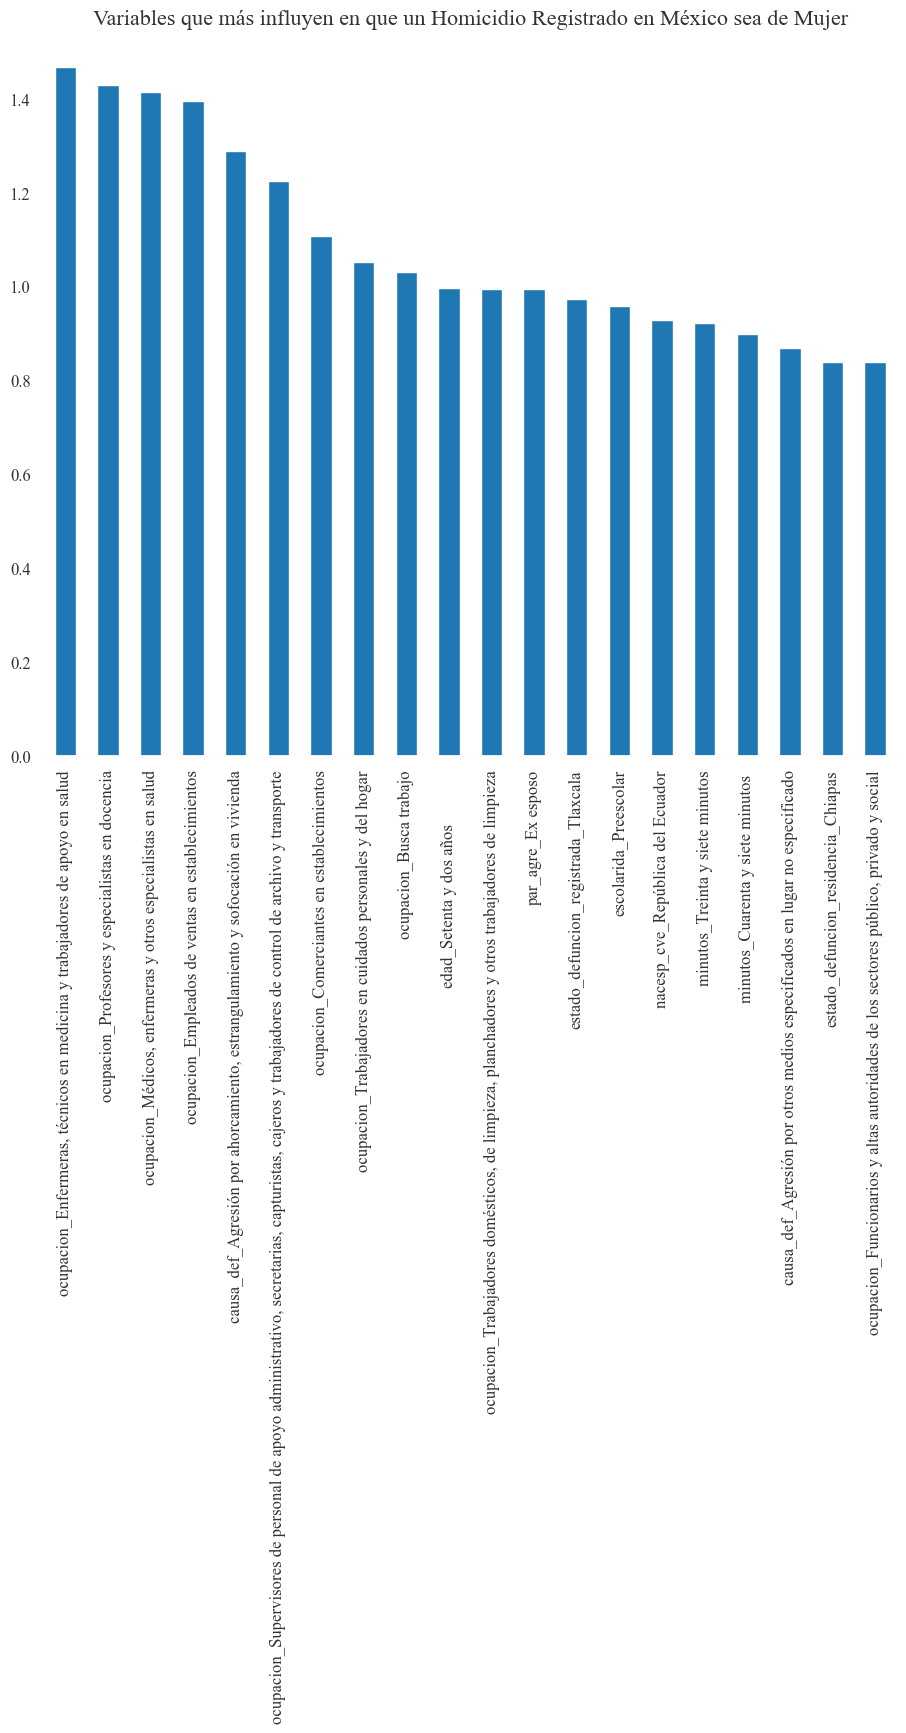

In [53]:
weights = pd.Series(model.coef_[0],
                    index=X.columns.values) 
print(weights.sort_values(ascending=False)[0:20].plot(kind='bar'))
plt.title('Variables que más influyen en que un Homicidio Registrado en México sea de Mujer', size = 16)

Axes(0.125,0.11;0.775x0.77)


Text(0.5, 1.0, 'Variables que menos influyen en que un Homicidio Registrado en México sea de Mujer')

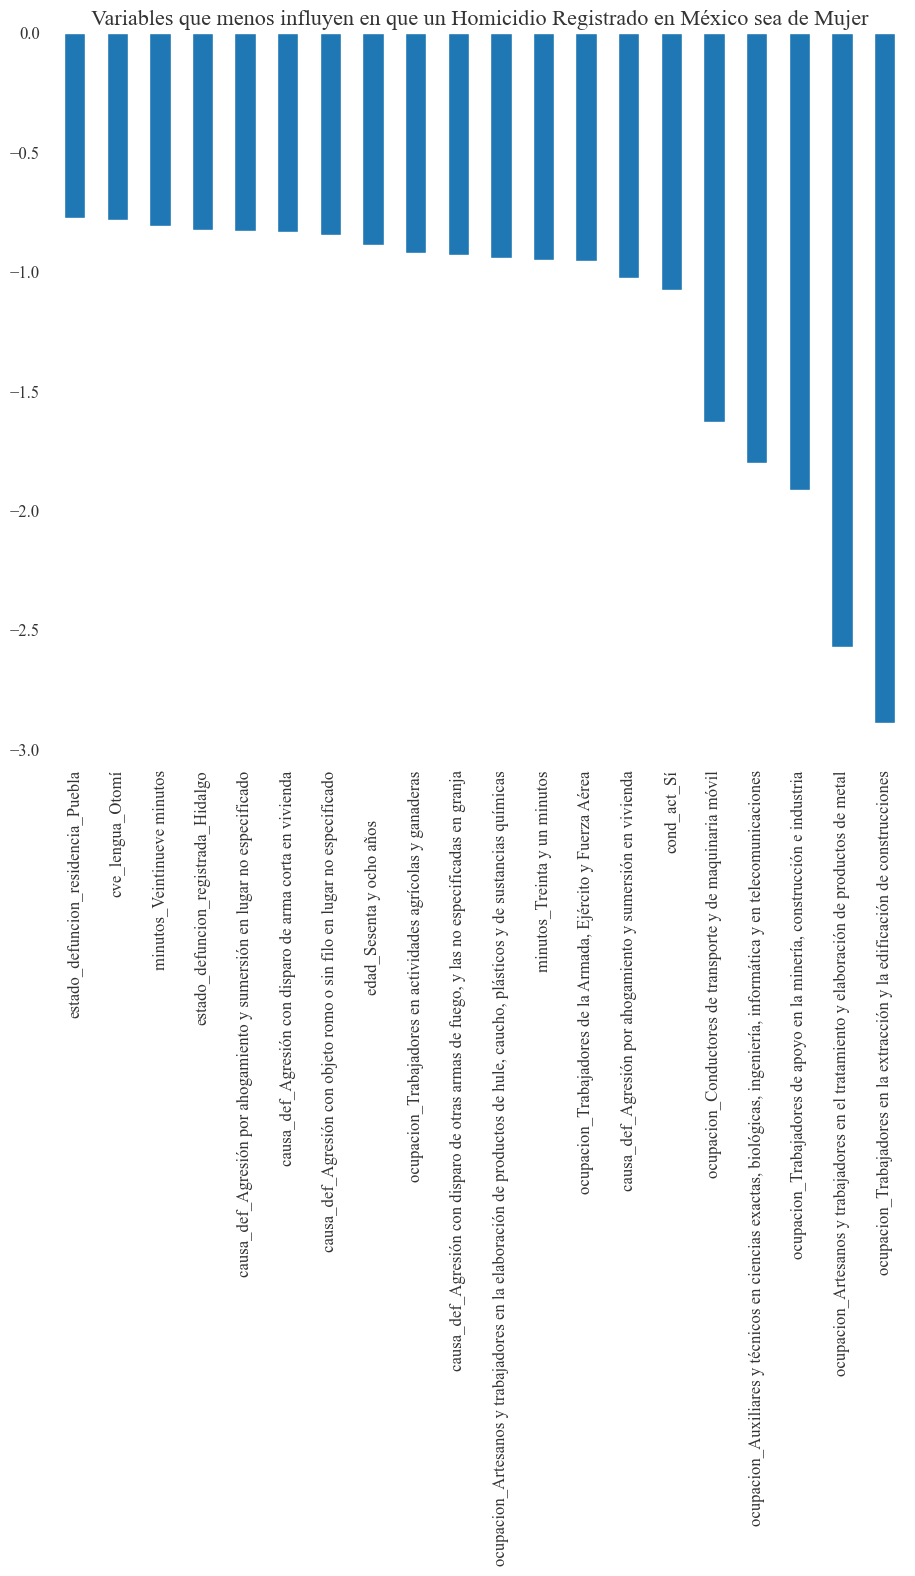

In [54]:
print(weights.sort_values(ascending=False)[-20:].plot(kind='bar'))
plt.title('Variables que menos influyen en que un Homicidio Registrado en México sea de Mujer', size = 16)

## Matriz de Confusión:

In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

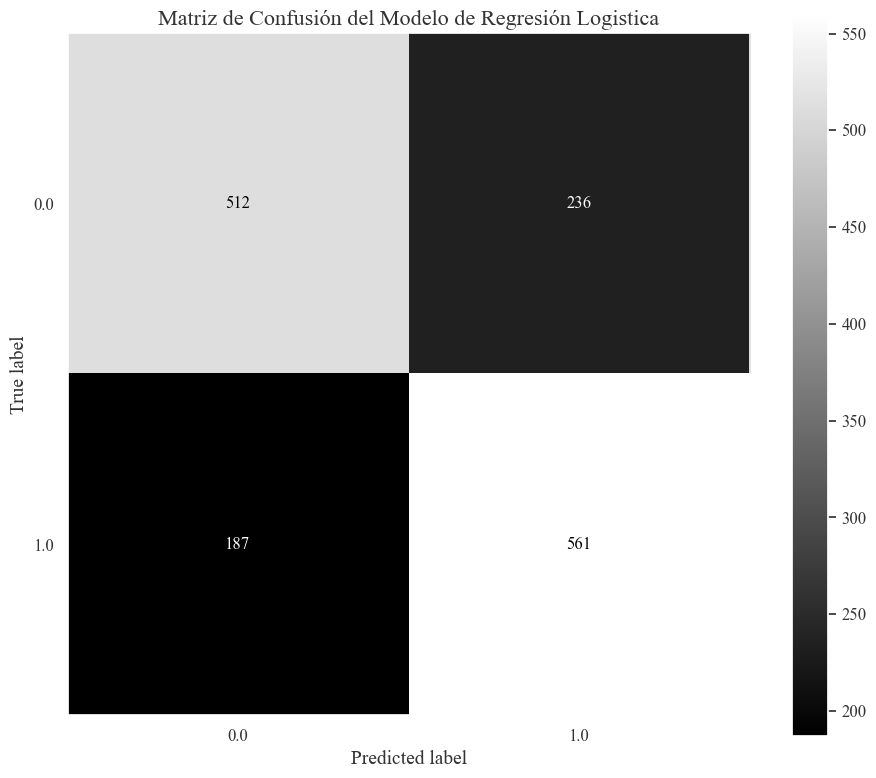

In [56]:
cm = confusion_matrix(y_test, prediction_test, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=model.classes_)
disp.plot(cmap='gray')
plt.title('Matriz de Confusión del Modelo de Regresión Logistica', size = 16)
plt.show()

## Reporte de Clasificación:

In [57]:
from sklearn.metrics import classification_report

print(classification_report(y_test, prediction_test))

              precision    recall  f1-score   support

         0.0       0.73      0.68      0.71       748
         1.0       0.70      0.75      0.73       748

    accuracy                           0.72      1496
   macro avg       0.72      0.72      0.72      1496
weighted avg       0.72      0.72      0.72      1496



## Curva ROC y UAC:

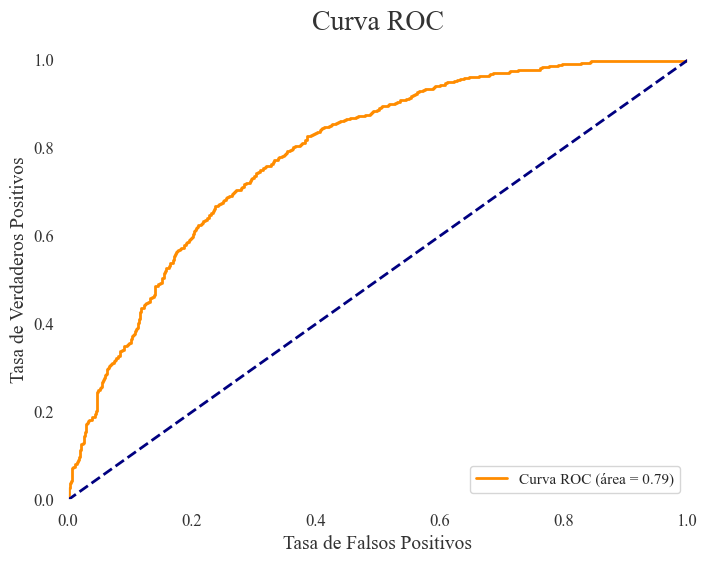

In [58]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Obtener las probabilidades predichas para la clase positiva
y_pred_prob = model.predict_proba(X_test)[:, 1]

# Calcular la curva ROC y el AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (área = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

## Curva Precision-Recall:

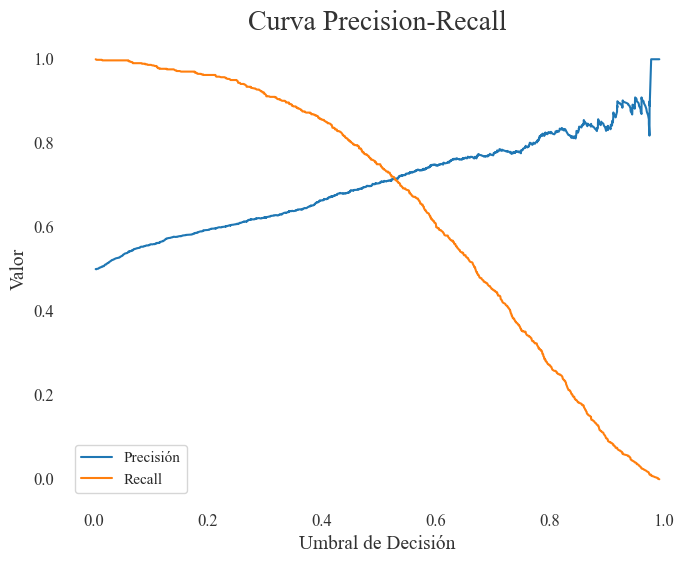

In [59]:
from sklearn.metrics import precision_recall_curve

# Calcular precisión, recall y umbrales
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_pred_prob)

# Graficar la curva Precision-Recall
plt.figure(figsize=(8, 6))
plt.plot(pr_thresholds, precisions[1:], label='Precisión')
plt.plot(pr_thresholds, recalls[1:], label='Recall')
plt.xlabel('Umbral de Decisión')
plt.ylabel('Valor')
plt.title('Curva Precision-Recall')
plt.legend()
plt.show()

## Validación Cruzada:

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print("Puntuaciones de validación cruzada (accuracy):", cv_scores)
print("Accuracy promedio:", cv_scores.mean())

## Balanced Accuracy:

In [60]:
from sklearn.metrics import balanced_accuracy_score

balanced_acc = balanced_accuracy_score(y_test, prediction_test)
print("Balanced Accuracy:", balanced_acc)

Balanced Accuracy: 0.7172459893048129
